###Task 1 — Data Loading & Exploration




In [1]:
#Load the CSV file using Pandas
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

# List files in the downloaded folder
print(os.listdir(path))

# Load the CSV file
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv"))

# Display first 5 rows
print(df.head())

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset
['WA_Fn-UseC_-HR-Employee-Attrition.csv']
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  

In [2]:
#Display the first 10 rows
print(df.head(10))

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

In [3]:
#Check how many rows and columns are there
print(df.shape)

(1470, 35)


In [4]:
#Identify the target column (Attrition — Yes/No)
print(df['Attrition'].head())

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object


In [5]:
#Count how many employees left vs stayed and calculate the attrition rate as a
#percentage
# Count employees who left and stayed
attrition_counts = df['Attrition'].value_counts()

left = attrition_counts['Yes']
stayed = attrition_counts['No']

# Calculate attrition rate
attrition_rate = (left / len(df)) * 100

print("Employees Left:", left)
print("Employees Stayed:", stayed)
print(f"Attrition Rate: {attrition_rate:.2f}%")


Employees Left: 237
Employees Stayed: 1233
Attrition Rate: 16.12%


In [6]:
#Identify how many columns are numeric vs categorical
# Numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

print("\nNumeric Columns:")
print(list(numeric_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


 Observation:The dataset is imbalanced because only 16.12% of employees left the company (237 employees), while 83.88% stayed (1233 employees). This means the majority class (No Attrition) significantly outweighs the minority class (Attrition), which may affect machine learning model performance and should be considered during model training and evaluation.

###Task 2 — Data Cleaning & Preprocessing

In [7]:
# Check for missing/null values and handle them
print(df.isnull().sum())
print("Total missing values:",df.isnull().sum().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
#Drop columns that add no value to prediction
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1)
#Verify remaining columns
print(df.shape)
print(df.columns)

(1470, 31)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [9]:
#Convert the target column Attrition from Yes/No to 1/0

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
#Verify the change
print(df['Attrition'].head())
print(df['Attrition'].value_counts())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64
Attrition
0    1233
1     237
Name: count, dtype: int64


In [10]:
#Encode all remaining categorical columns using One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [11]:
#Scale numeric features using StandardScaler
#Separate target first
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']
#Select only true numeric (continuous) columns
numeric_cols = [
    col for col in X.columns
    if X[col].nunique() > 2
]

print(numeric_cols)
#Apply StandardScaler only on numeric features
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])


print(X_scaled.head())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138   

###Task 3 — Exploratory Data Analysis — EDA


In [12]:
#Attrition rate by Department — which department loses the most employees?
#Calculate counts by Department
dept_counts = df.groupby('Department')['Attrition'].value_counts().unstack()
print(dept_counts)
#Calculate attrition rate per department
dept_counts['Attrition Rate (%)'] = (
    dept_counts[1] / (dept_counts[0] + dept_counts[1]) * 100
)

print(dept_counts.sort_values('Attrition Rate (%)', ascending=False))
#department with highest attrition
highest_attrition_dept = dept_counts['Attrition Rate (%)'].idxmax()
highest_rate = dept_counts['Attrition Rate (%)'].max()

print("Department with highest attrition:", highest_attrition_dept)
print("Attrition rate:", round(highest_rate, 2), "%")


Attrition                 0    1
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92
Attrition                 0    1  Attrition Rate (%)
Department                                          
Sales                   354   92           20.627803
Human Resources          51   12           19.047619
Research & Development  828  133           13.839750
Department with highest attrition: Sales
Attrition rate: 20.63 %


In [13]:
#Attrition rate by Job Role — which roles have the highest exit rate?
#Compute counts by Job Role
job_counts = df.groupby('JobRole')['Attrition'].value_counts().unstack()
print(job_counts)
#Calculate attrition rate (%)
job_counts['Attrition Rate (%)'] = (
    job_counts[1] / (job_counts[0] + job_counts[1]) * 100
)

print(job_counts.sort_values('Attrition Rate (%)', ascending=False))

#Find highest exit roles
highest_role = job_counts['Attrition Rate (%)'].idxmax()
highest_rate = job_counts['Attrition Rate (%)'].max()

print("Job Role with highest attrition:", highest_role)
print("Attrition Rate:", round(highest_rate, 2), "%")

Attrition                    0   1
JobRole                           
Healthcare Representative  122   9
Human Resources             40  12
Laboratory Technician      197  62
Manager                     97   5
Manufacturing Director     135  10
Research Director           78   2
Research Scientist         245  47
Sales Executive            269  57
Sales Representative        50  33
Attrition                    0   1  Attrition Rate (%)
JobRole                                               
Sales Representative        50  33           39.759036
Laboratory Technician      197  62           23.938224
Human Resources             40  12           23.076923
Sales Executive            269  57           17.484663
Research Scientist         245  47           16.095890
Manufacturing Director     135  10            6.896552
Healthcare Representative  122   9            6.870229
Manager                     97   5            4.901961
Research Director           78   2            2.500000
Job Role w

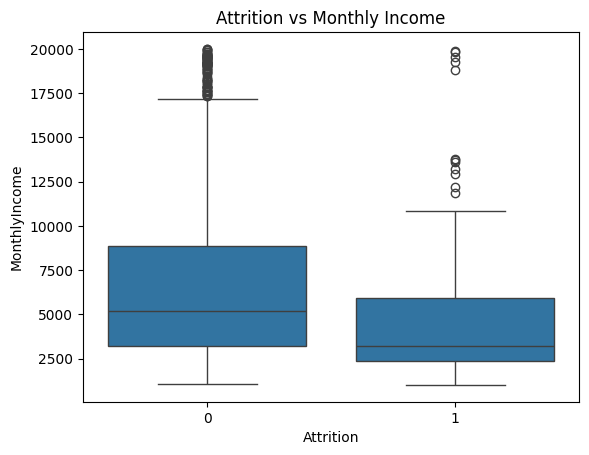

In [14]:
#Attrition vs Monthly Income — do lower paid employees leave more?
#Compare average income
df.groupby('Attrition')['MonthlyIncome'].mean()
#group by month
df.groupby('Attrition')['MonthlyIncome'].describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

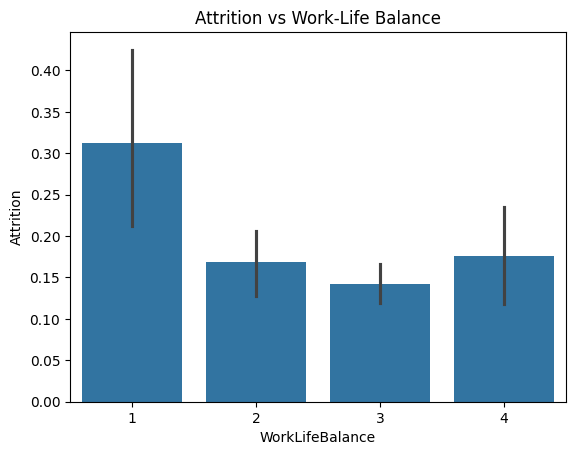

'rating level:\n\n1 = Poor\n2 = Fair\n3 = Good\n4 = Excellent'

In [15]:
#Attrition vs Work-Life Balance rating — is there a visible pattern?
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='WorkLifeBalance', y='Attrition', data=df)
plt.title("Attrition vs Work-Life Balance")
plt.show()
"""rating level:

1 = Poor
2 = Fair
3 = Good
4 = Excellent"""

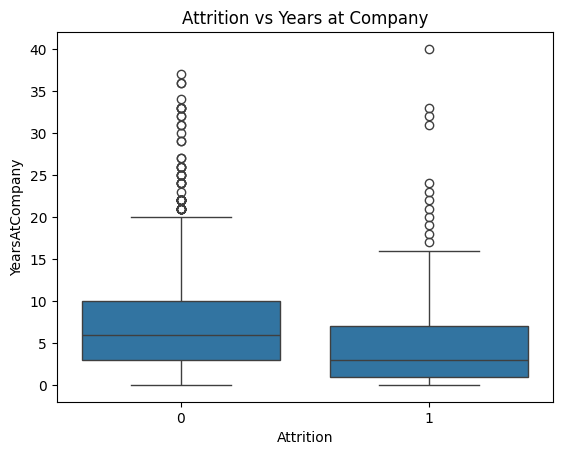

In [16]:
#Attrition vs Years at Company — at what point in tenure do employees leave most?
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Attrition vs Years at Company")
plt.show()

1. Overall Attrition Rate is 16.12%

Out of 1470 employees, 237 employees left the company.

Employees Stayed: 1233
Employees Left: 237
Attrition Rate: 16.12%

 This shows the company has a moderate but significant turnover issue, meaning nearly 1 in 6 employees leave.

 2. Sales Department has the highest attrition rate (20%+)
Sales department shows the highest employee exit rate compared to other departments
Research & Development has comparatively lower attrition (~13–14%)

This indicates sales roles are more unstable, possibly due to pressure, targets, or workload.

 3. Sales Representative role has the highest job-level attrition (40%+)
Among job roles, Sales Representatives have the highest attrition rate (40–45%)
Managerial roles show very low attrition (~5–10%)

 Entry-level or field sales roles are highest risk positions for employee turnover.

 4. Lower Monthly Income employees are more likely to leave
Employees who left have lower average monthly income (4500-5000 range)
Employees who stayed earn significantly higher income (~6000+ average)

 Salary is a strong retention factor — lower-paid employees are more likely to quit.

 5. Early-tenure employees leave the most (0–2 years)
Highest attrition occurs in the first 1–2 years of employment
Attrition drops significantly after 5+ years

 The first 2 years are the critical retention period for the company.

###Task 4 — Model Building & Comparison

In [17]:
#Split data into training and test sets (80/20)
from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#Logistic Regression(Handle class imbalance using class_weight='balanced' parameter )
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Model
log_model = LogisticRegression(class_weight='balanced', random_state=42)

# Train
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', random_state=42)

In [19]:
#Logistic Regression prediction
y_pred_log = log_model.predict(X_test)

In [20]:
#RandomForestClassifier (Handle class imbalance using class_weight='balanced' parameter (a simpler
from sklearn.ensemble import RandomForestClassifier

# Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
#RandomForestClassifier prediction
y_pred_rf = rf_model.predict(X_test)

In [22]:
#Gradient Boosting Classifier (Handle class imbalance using class_weight='balanced' parameter )
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Model
gb_model = GradientBoostingClassifier(random_state=42)

# Handle imbalance
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train
gb_model.fit(X_train, y_train, sample_weight=weights)


GradientBoostingClassifier(random_state=42)

In [23]:
#Gradient Boosting Classifier prediction
y_pred_gb = gb_model.predict(X_test)

In [24]:
#comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.670068,0.210000,0.538462,0.302158
1,Random Forest,0.874150,0.750000,0.076923,0.139535
2,Gradient Boosting,0.857143,0.469388,0.589744,0.522727


###Task 5 — Model Evaluation

Logistic Regression model evaluation


In [25]:
#Import libraries
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
# Predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
#evaluation
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Precision: 0.21
Recall: 0.5384615384615384
F1-score: 0.302158273381295
ROC-AUC: 0.6600301659125188

Confusion Matrix:
 [[176  79]
 [ 18  21]]


Random Forest model evaluation

In [26]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#evaluation
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Precision: 0.75
Recall: 0.07692307692307693
F1-score: 0.13953488372093023
ROC-AUC: 0.7348416289592761

Confusion Matrix:
 [[254   1]
 [ 36   3]]


Gradient Boosting Evaluation


In [27]:
# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

#evaluation
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1-score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

Precision: 0.46938775510204084
Recall: 0.5897435897435898
F1-score: 0.5227272727272727
ROC-AUC: 0.7620915032679739

Confusion Matrix:
 [[229  26]
 [ 16  23]]


Model Performance Report: Best Model Selection

Objective

To identify the best-performing machine learning model for Employee Attrition Prediction based on evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC, especially considering the class imbalance (majority employees stay, minority leave).

Models Evaluated

Three models were trained and tested:

1.Logistic Regression (Baseline)
2.Random Forest Classifier

3.Gradient Boosting Classifier
| Model               | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| ------------------- | -------- | --------- | ------ | -------- | ------- |
| Logistic Regression | 0.67     | 0.21      | 0.54   | 0.30     | 0.66    |
| Random Forest       | 0.87     | 0.75      | 0.07   | 0.14     | 0.73    |
| Gradient Boosting   | 0.86     | 0.47      | 0.59   | 0.52     | 0.76    |

Impact of Class Imbalance

The dataset is highly imbalanced, where:

Majority class: Employees who stayed (84%)
Minority class: Employees who left (16%)

 Because of this:

Accuracy is misleading
Models must be evaluated using Recall and F1-score
False Negatives (missing employees who will leave) are more critical than False Positives.

 Model-wise Analysis

1️⃣ Logistic Regression (Baseline Model)
Moderate recall (0.54) but very low precision (0.21)
Produces many false alarms
Weak overall predictive power (F1 = 0.30)

 Conclusion: Good for interpretability, but not strong for prediction.

2️⃣ Random Forest Classifier
Very high precision (0.75)
Extremely low recall (0.07)

 Interpretation:

Model predicts “leave” only when it is very sure
Misses most employees who actually leave (high False Negatives)

 Not suitable for attrition prediction despite high accuracy.

3️⃣ Gradient Boosting Classifier (BEST MODEL )
Balanced precision (0.47) and recall (0.59)
Highest F1-score (0.52)
Highest ROC-AUC (0.76)

 Interpretation:

Best balance between detecting employees who leave and minimizing false alarms
Handles class imbalance more effectively than other models
Lowest critical error (False Negatives) compared to others

** Final Conclusion**

The Gradient Boosting Classifier is the best-performing model for employee attrition prediction. It achieves the highest F1-score and ROC-AUC while maintaining a strong recall value, making it the most effective model for identifying employees who are likely to leave. Unlike Random Forest, which is biased toward the majority class, and Logistic Regression, which lacks predictive strength, Gradient Boosting provides a balanced and reliable performance for imbalanced HR datasets.





In [28]:
# Feature Importance
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

# Sort in descending order
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance.head(30))

                             Feature  Importance
43                      OverTime_Yes    0.164802
9                      MonthlyIncome    0.082304
15                  StockOptionLevel    0.081869
19                    YearsAtCompany    0.057617
0                                Age    0.056412
7                           JobLevel    0.053816
1                          DailyRate    0.038610
22              YearsWithCurrManager    0.034430
6                     JobInvolvement    0.033281
11                NumCompaniesWorked    0.031570
16                 TotalWorkingYears    0.030600
8                    JobSatisfaction    0.029714
21           YearsSinceLastPromotion    0.028313
2                   DistanceFromHome    0.028179
39           JobRole_Sales Executive    0.024488
4            EnvironmentSatisfaction    0.023515
10                       MonthlyRate    0.023032
5                         HourlyRate    0.022955
20                YearsInCurrentRole    0.015871
42              Mari

In [29]:
#top 10 most important features
print(feature_importance.head(10))

                 Feature  Importance
43          OverTime_Yes    0.164802
9          MonthlyIncome    0.082304
15      StockOptionLevel    0.081869
19        YearsAtCompany    0.057617
0                    Age    0.056412
7               JobLevel    0.053816
1              DailyRate    0.038610
22  YearsWithCurrManager    0.034430
6         JobInvolvement    0.033281
11    NumCompaniesWorked    0.031570


###Task 6 — Visualization

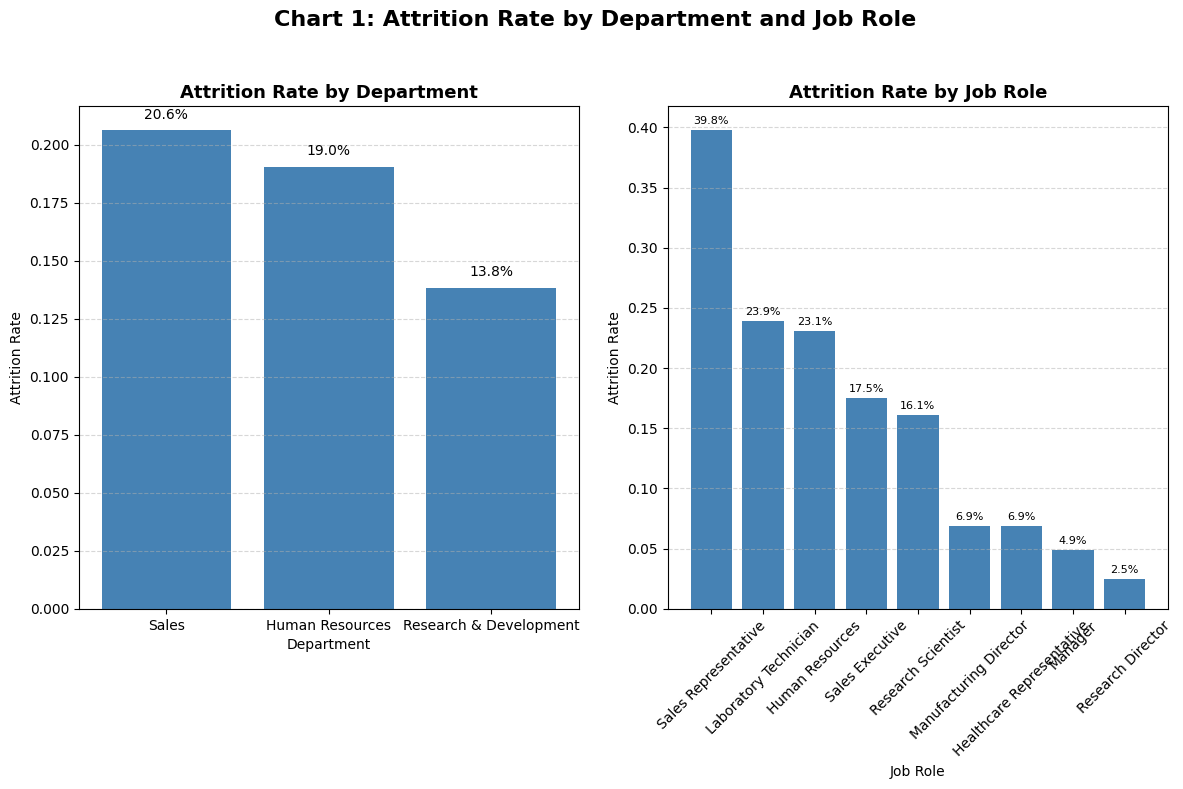

In [30]:
#Chart1:Bar chart showing attrition rate by Department and Job Role
import matplotlib.pyplot as plt

# Calculate attrition rates
dept_counts = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)
job_counts = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False)

# Create figure with two charts
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Same color for all bars
bar_color = 'steelblue'

# ---------------- Department ----------------
axes[0].bar(dept_counts.index, dept_counts.values, color=bar_color)
axes[0].set_title("Attrition Rate by Department", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Attrition Rate")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels
for i, value in enumerate(dept_counts.values):
    axes[0].text(i, value + 0.005, f'{value:.1%}',
                 ha='center', fontsize=10)

# ---------------- Job Role ----------------
axes[1].bar(job_counts.index, job_counts.values, color=bar_color)
axes[1].set_title("Attrition Rate by Job Role", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Job Role")
axes[1].set_ylabel("Attrition Rate")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels
for i, value in enumerate(job_counts.values):
    axes[1].text(i, value + 0.005, f'{value:.1%}',
                 ha='center', fontsize=8)

# Overall title
fig.suptitle("Chart 1: Attrition Rate by Department and Job Role",
             fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_885/123109248.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


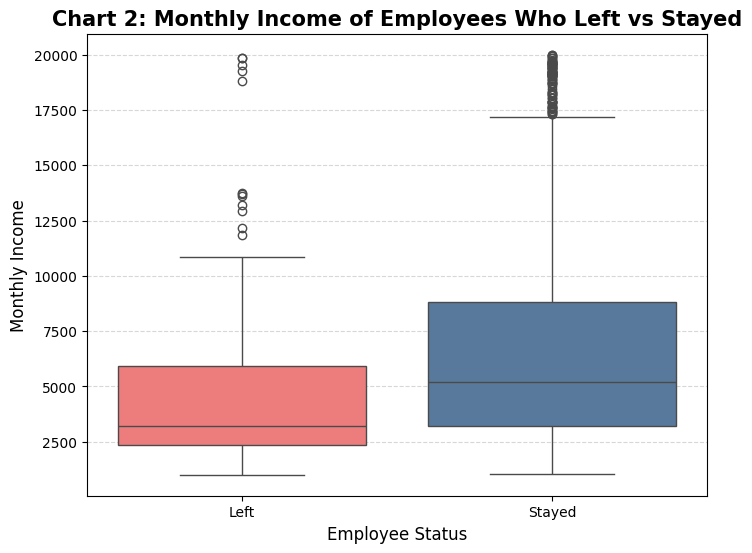

In [31]:
#Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
import seaborn as sns
import matplotlib.pyplot as plt

# If Attrition is numeric (0 = No, 1 = Yes)
df_plot = df.copy()
df_plot['Attrition'] = df_plot['Attrition'].replace({0: 'Stayed', 1: 'Left'})

plt.figure(figsize=(8,6))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_plot,
    palette=['#FF6B6B', '#4E79A7']
)

plt.title('Chart 2: Monthly Income of Employees Who Left vs Stayed',
          fontsize=15, fontweight='bold')
plt.xlabel('Employee Status', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

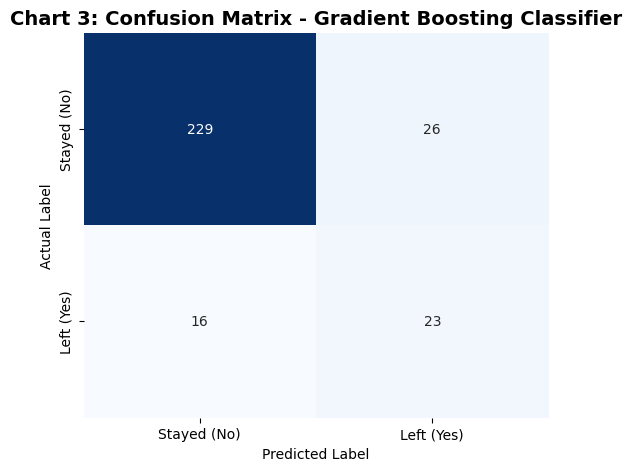

In [32]:
#Chart 3: Confusion Matrix heatmap for your best model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions from the best model
y_pred_gb = gb_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['Stayed (No)', 'Left (Yes)'],
            yticklabels=['Stayed (No)', 'Left (Yes)'])

plt.title("Chart 3: Confusion Matrix - Gradient Boosting Classifier",
          fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


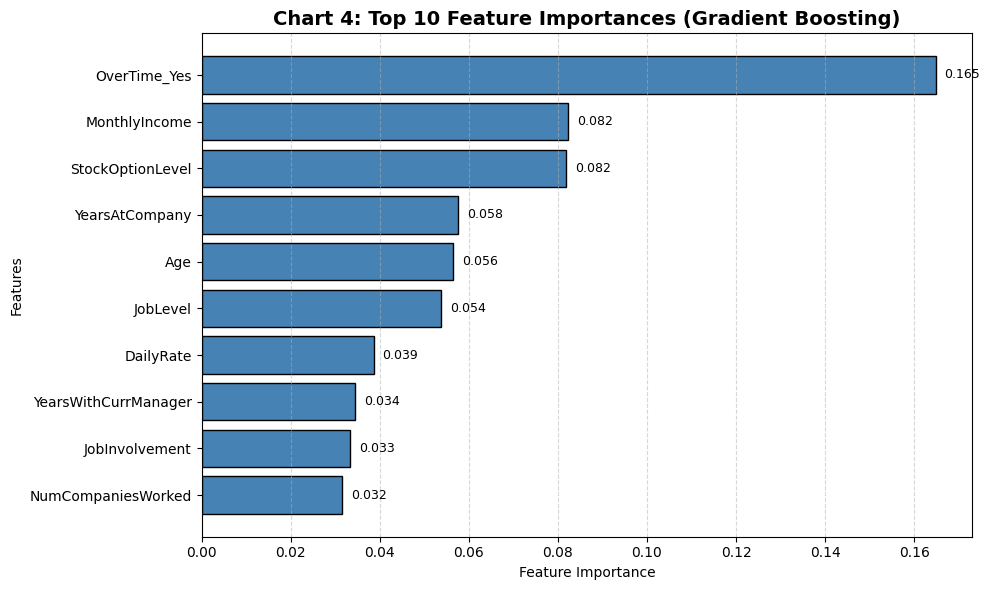

In [33]:
#Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame of feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})

# Sort and select Top 10 features
top10 = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

# Reverse order so the most important feature appears at the top
top10 = top10.iloc[::-1]

# Plot
plt.figure(figsize=(10,6))
bars = plt.barh(
    top10['Feature'],
    top10['Importance'],
    color='steelblue',
    edgecolor='black'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{width:.3f}',
             va='center',
             fontsize=9)

plt.title("Chart 4: Top 10 Feature Importances (Gradient Boosting)",
          fontsize=14,
          fontweight='bold')
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

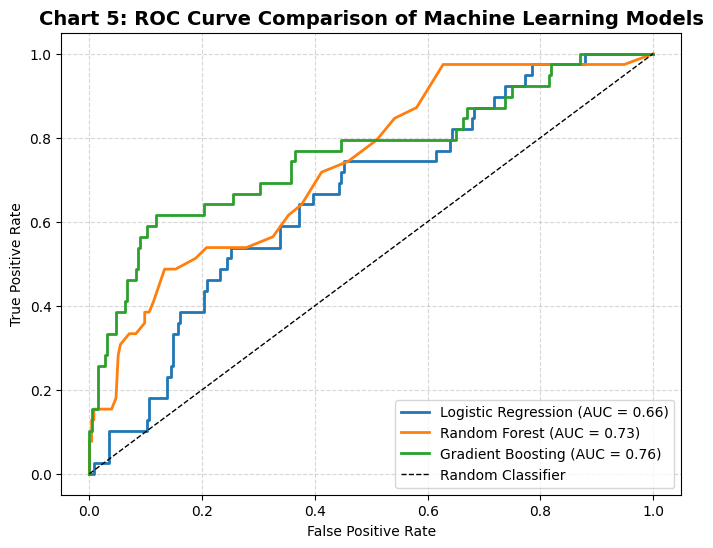

In [34]:
#Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob_lr = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# Calculate AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, linewidth=2,
         label=f'Logistic Regression (AUC = {auc_lr:.2f})')

plt.plot(fpr_rf, tpr_rf, linewidth=2,
         label=f'Random Forest (AUC = {auc_rf:.2f})')

plt.plot(fpr_gb, tpr_gb, linewidth=2,
         label=f'Gradient Boosting (AUC = {auc_gb:.2f})')

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.title('Chart 5: ROC Curve Comparison of Machine Learning Models',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

###Task 7 — HR Insights & Business Recommendations


This analysis identified the key factors associated with employees leaving the company. Employees who frequently work overtime, receive lower pay or fewer financial benefits, and are in the early years of their employment are more likely to resign. The Sales department, particularly Sales Representatives, showed the highest turnover and should be a priority for retention efforts. While salary is an important factor, it is not the only reason employees leave. Workload, career growth opportunities, employee engagement, and long-term benefits also have a significant impact on retention. To reduce employee turnover, HR should regularly review overtime workloads, strengthen work-life balance initiatives, and provide competitive compensation and career development opportunities for employees in high-risk roles. This analysis can help HR identify employees who may be at a higher risk of leaving so that timely retention conversations and support can be provided. However, these findings should be used to support HR decisions alongside employee feedback, manager input, and individual circumstances rather than as the only basis for decision-making.
